# 🌱 MicroAgri-FP4: Fine-Tuning Tiny ViT + Simulated Microscaling FP4 Quantization

**Project:** MicroAgri-FP4 — Simulated Microscaling FP4 Quantization for Vision Transformer-Based Crop Health Monitoring

**This notebook covers:**
1. **Phase 1:** Fine-tune a tiny ViT (DeiT-Tiny / MobileViT-XS / EfficientFormerV2-S0) on PlantVillage dataset
2. **Phase 2:** Simulate MXFP4 & NVFP4 microscaling quantization (from Castro et al.)
3. **Phase 3:** Apply GPTQ-style post-training quantization adapted for FP4 grids
4. **Phase 4:** Distribution analysis — replicate Figure 2 style analysis from the paper
5. **Phase 5:** Export quantized model for edge deployment (ONNX + TFLite)

**Hardware:** Google Colab Free Tier (T4 GPU, ~15GB VRAM)

**Reference:** Castro et al., *Bridging the Gap Between Promise and Performance for Microscaling FP4 Quantization* (2025)

---

## 0. Environment Setup & Dependencies

In [ ]:
# Check GPU availability
!nvidia-smi

import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Tue Mar  3 10:10:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   50C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [1]:
%%capture
# Install required packages
!pip install timm transformers datasets accelerate
!pip install torchmetrics scikit-learn
!pip install onnx onnxruntime
!pip install matplotlib seaborn scipy
!pip install auto-gptq --no-build-isolation  # For GPTQ reference


In [2]:
import os
import sys
import math
import json
import time
import copy
import warnings
import numpy as np
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder

import timm
from torchmetrics import Accuracy, F1Score, ConfusionMatrix
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import laplace, norm

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


---
## 1. Dataset: PlantVillage from Google Drive

The PlantVillage dataset has **38 classes** across ~54K images in a folder-per-class structure:
```
PlantVillage/
├── color/
│   ├── Apple___Apple_scab/
│   ├── Apple___Black_rot/
│   ├── ...
│   └── Tomato___healthy/
├── grayscale/
└── segmented/
```
We use the **color** directory.

In [5]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Expected structure
#   PlantVillage/
#     Pepper_bell_Bacterial_spot/
#     Pepper_bell_healthy/
#     Potato_Early_blight/
#     Potato_Late_blight/
#     Potato_healthy/
#     Tomato_Bacterial_spot/
#     Tomato_Early_blight/
#     Tomato_Late_blight/
#     Tomato_Leaf_Mold/
#     Tomato_Septoria_leaf_spot/
#     Tomato_Spider_mites_Two_spotted_spider_mite/
#     Tomato_Target_Spot/
#     Tomato_Tomato_YellowLeaf_Curl_Virus/
#     Tomato_Tomato_mosaic_virus/
#     Tomato_healthy/

DRIVE_DATASET_PATH = "/content/drive/MyDrive/CSE499BDatasets/Plant-Village.zip"

import zipfile
import glob

# If zip file, extract it first
if DRIVE_DATASET_PATH.endswith('.zip'):
    print("extracting zip file")
    with zipfile.ZipFile(DRIVE_DATASET_PATH, 'r') as z:
        z.extractall('/content/plantvillage_raw')
    RAW_DIR = '/content/plantvillage_raw'
else:
    RAW_DIR = DRIVE_DATASET_PATH

#auto-detect the dataset directory
#handles multiple PlantVillage variants
#any nested zip structure


def find_dataset_dir(base_path):
    """Search for the directory containing class subfolders."""
    plant_keywords = [
        'Tomato', 'Potato', 'Pepper', 'Apple', 'Corn', 'Grape',
        'Cherry', 'Peach', 'Strawberry', 'Soybean', 'Squash',
    ]

    def looks_like_plantvillage(dirpath):
        if not os.path.isdir(dirpath):
            return False
        subdirs = [d for d in os.listdir(dirpath)
                   if os.path.isdir(os.path.join(dirpath, d))]
        if len(subdirs) < 3:
            return False
        matches = sum(1 for d in subdirs
                      if any(kw in d for kw in plant_keywords))
        return matches >= 3

    #check direct paths first
    candidates = [
        base_path,
        os.path.join(base_path, 'PlantVillage'),
        os.path.join(base_path, 'plantvillage'),
        os.path.join(base_path, 'color'),
        os.path.join(base_path, 'plantvillage dataset', 'color'),
        os.path.join(base_path, 'PlantVillage', 'color'),
    ]

    for p in candidates:
        if looks_like_plantvillage(p):
            return p

    #recursive search (max depth 3)
    print("searching recursively for dataset directory")
    for root, dirs, files in os.walk(base_path):
        depth = root.replace(base_path, '').count(os.sep)
        if depth > 3:
            continue
        if looks_like_plantvillage(root):
            return root

    return None

DATA_DIR = find_dataset_dir(RAW_DIR)

assert DATA_DIR is not None, (
    f"Could not find PlantVillage dataset directory.\n"
    f"Searched in: {RAW_DIR}\n"
    f"Contents: {os.listdir(RAW_DIR) if os.path.isdir(RAW_DIR) else 'NOT A DIR'}\n"
    f"Please edit DRIVE_DATASET_PATH to point to the folder containing "
    f"subfolders like Pepper_bell_healthy/, Tomato_Early_blight/, etc."
)

classes = sorted([d for d in os.listdir(DATA_DIR)
                  if os.path.isdir(os.path.join(DATA_DIR, d))])
total_images = sum(
    len([f for f in os.listdir(os.path.join(DATA_DIR, c))
         if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    for c in classes
)

print(f"Dataset directory: {DATA_DIR}")
print(f"Number of classes: {len(classes)}")
print(f"Total images: {total_images:,}")
print(f"\nAll classes:")
for i, c in enumerate(classes):
    n = len([f for f in os.listdir(os.path.join(DATA_DIR, c))
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    print(f"  {i+1:>2}. {c} ({n} images)")

extracting zip file
Dataset directory: /content/plantvillage_raw/PlantVillage
Number of classes: 15
Total images: 20,638

All classes:
   1. Pepper__bell___Bacterial_spot (997 images)
   2. Pepper__bell___healthy (1478 images)
   3. Potato___Early_blight (1000 images)
   4. Potato___Late_blight (1000 images)
   5. Potato___healthy (152 images)
   6. Tomato_Bacterial_spot (2127 images)
   7. Tomato_Early_blight (1000 images)
   8. Tomato_Late_blight (1909 images)
   9. Tomato_Leaf_Mold (952 images)
  10. Tomato_Septoria_leaf_spot (1771 images)
  11. Tomato_Spider_mites_Two_spotted_spider_mite (1676 images)
  12. Tomato__Target_Spot (1404 images)
  13. Tomato__Tomato_YellowLeaf__Curl_Virus (3208 images)
  14. Tomato__Tomato_mosaic_virus (373 images)
  15. Tomato_healthy (1591 images)


In [ ]:
# Split into train/val/test (80/10/10)
!pip install split-folders
import splitfolders

SPLIT_DIR ='/content/drive/MyDrive/CSE499BDatasets/plantvillage_split'
if not os.path.exists(SPLIT_DIR):
    splitfolders.ratio(
        DATA_DIR,
        output=SPLIT_DIR,
        seed=42,
        ratio=(0.8, 0.1, 0.1),
        group_prefix=None
    )
    print("dataset split complete")
else:
    print("split already exists")

for split in ['train', 'val', 'test']:
    n = sum(len(files) for _, _, files in os.walk(os.path.join(SPLIT_DIR, split)))
    print(f"  {split}: {n} images")

split already exists
  train: 16505 images
  val: 2058 images
  test: 2076 images


---
## 2. Data Loading & Augmentation

Following the roadmap — image size 224x224 for DeiT-Tiny, with agricultural-specific augmentations.

In [ ]:
#HYPERPARAMETERS — optimized for speed on T4
IMG_SIZE = 224
BATCH_SIZE = 128        # 2x larger — fits on T4 with mixed precision
NUM_EPOCHS = 10         # PlantVillage converges fast with pretrained ViT
LEARNING_RATE = 1e-4    # Scaled up with batch size (linear scaling rule)
WEIGHT_DECAY = 0.05
WARMUP_EPOCHS = 1
LABEL_SMOOTHING = 0.1
NUM_WORKERS = 2         # Colab has 2 CPU cores but 4 workers still helps with prefetching
SEED = 42
USE_AMP = True          # Mixed precision flag (used in training loop)

torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [ ]:
# Copy dataset to local disk for fast I/O
import shutil

LOCAL_SPLIT_DIR = '/content/plantvillage_split'
if not os.path.exists(LOCAL_SPLIT_DIR):
    print("copying dataset from Drive to local disk")
    shutil.copytree(SPLIT_DIR, LOCAL_SPLIT_DIR)
    print("Done.")
else:
    print("local copy already exists.")

# Use local path for dataloaders
SPLIT_DIR_FAST = LOCAL_SPLIT_DIR

copying dataset from Drive to local disk


KeyboardInterrupt: 

In [ ]:
# Data transforms — agricultural-specific augmentation
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize(int(IMG_SIZE * 1.14)),  # 256 for 224 crop
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Create datasets
train_dataset = ImageFolder(os.path.join(SPLIT_DIR, 'train'), transform=train_transform)
val_dataset   = ImageFolder(os.path.join(SPLIT_DIR, 'val'),   transform=val_transform)
test_dataset  = ImageFolder(os.path.join(SPLIT_DIR, 'test'),  transform=val_transform)

NUM_CLASSES = len(train_dataset.classes)
CLASS_NAMES = train_dataset.classes
print(f"Number of classes: {NUM_CLASSES}")
print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

# Dataloaders
#train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
#                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
#val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
 #                         num_workers=NUM_WORKERS, pin_memory=True)
#test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
 #                         num_workers=NUM_WORKERS, pin_memory=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True,
                          persistent_workers=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True,
                          persistent_workers=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True,
                          persistent_workers=False)

Number of classes: 15
Train: 16504, Val: 2058, Test: 2076


In [ ]:
print(f"Loading from: {SPLIT_DIR_FAST}")
print(f"Is local disk: {SPLIT_DIR_FAST.startswith('/content/plantvillage')}")

Loading from: /content/plantvillage_split
Is local disk: True


---
## 3. Model: DeiT-Tiny (Tier 1 MicroAgri-ViT)

From the roadmap, we use **DeiT-Tiny** as the primary tiny ViT backbone:
- ~5.7M parameters
- 192 embedding dimension, 12 layers, 3 attention heads
- Pretrained on ImageNet → fine-tune on PlantVillage

We also prepare alternative models for comparison: **MobileViT-XS** and **EfficientFormerV2-S0**.

In [ ]:
# MODEL SELECTION
# Options from the roadmap:
#   'deit_tiny_patch16_224'          — 5.7M params, pure ViT
#   'mobilevitv2_050'                — 1.4M params, hybrid CNN-ViT
#   'efficientformerv2_s0'           — 3.5M params, efficient ViT

MODEL_NAME = 'deit_tiny_patch16_224'

def create_model(model_name, num_classes, pretrained=True):
    """Create a timm model with custom classification head."""
    model = timm.create_model(
        model_name,
        pretrained=pretrained,
        num_classes=num_classes,
        drop_rate=0.1,
        drop_path_rate=0.1,
    )
    return model

model = create_model(MODEL_NAME, NUM_CLASSES).to(device)

# Model summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
model_size_mb = total_params * 4 / (1024**2)  # FP32
model_size_fp4 = total_params * 0.53125 / (1024**2)  # FP4 (4.25 bits)

print(f"Model: {MODEL_NAME}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model size (FP32): {model_size_mb:.1f} MB")
print(f"Model size (MXFP4, 4.25 bpw): {model_size_fp4:.1f} MB")
print(f"Model size (NVFP4, 4.5 bpw): {total_params * 0.5625 / (1024**2):.1f} MB")

model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

Model: deit_tiny_patch16_224
Total parameters: 5,527,311
Trainable parameters: 5,527,311
Model size (FP32): 21.1 MB
Model size (MXFP4, 4.25 bpw): 2.8 MB
Model size (NVFP4, 4.5 bpw): 3.0 MB


In [8]:
# MODEL SELECTION + LOAD
MODEL_NAME = 'deit_tiny_patch16_224'

def create_model(model_name, num_classes, pretrained=True):
    """Create a timm model with custom classification head."""
    model = timm.create_model(
        model_name,
        pretrained=pretrained,
        num_classes=num_classes,
        drop_rate=0.1,
        drop_path_rate=0.1,
    )
    return model

# Try loading trained model from Drive, otherwise create fresh
BASELINE_PATH = '/content/drive/MyDrive/CSE499BDatasets/microagri_vit_fp32_baseline.pth'

if os.path.exists(BASELINE_PATH):
    print("Found saved model on Drive, loading...")
    checkpoint = torch.load(BASELINE_PATH, map_location=device)
    model = create_model(checkpoint['model_name'], checkpoint['num_classes'], pretrained=False).to(device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    NUM_CLASSES = checkpoint['num_classes']
    CLASS_NAMES = checkpoint['class_names']
    best_model_state = checkpoint['model_state_dict']
    history = checkpoint.get('history', {})
    print(f"Loaded {checkpoint['model_name']} — Test Acc: {checkpoint['test_acc']:.4f}")
else:
    print("No saved model found, creating fresh pretrained model")
    model = create_model(MODEL_NAME, NUM_CLASSES).to(device)
    print("Run the training cells to train and save the model.")

# Model summary
total_params = sum(p.numel() for p in model.parameters())
model_size_mb = total_params * 4 / (1024**2)
print(f"\nModel: {MODEL_NAME}")
print(f"Total parameters: {total_params:,}")
print(f"Model size (FP32): {model_size_mb:.1f} MB")
print(f"Model size (MXFP4, 4.25 bpw): {total_params * 0.53125 / (1024**2):.1f} MB")
print(f"Model size (NVFP4, 4.5 bpw): {total_params * 0.5625 / (1024**2):.1f} MB")

Found saved model on Drive, loading...
Loaded deit_tiny_patch16_224 — Test Acc: 0.9981

Model: deit_tiny_patch16_224
Total parameters: 5,527,311
Model size (FP32): 21.1 MB
Model size (MXFP4, 4.25 bpw): 2.8 MB
Model size (NVFP4, 4.5 bpw): 3.0 MB


---
## 4. Training Loop

**Optimizer:** AdamW (β₁=0.9, β₂=0.999) — standard for ViT fine-tuning

**Scheduler:** Cosine annealing with linear warmup

**Loss:** Cross-entropy with label smoothing (0.1)

In [ ]:
# Optimizer & Scheduler (from DeiT training recipe)
optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.999)
)

# Cosine annealing after warmup
scheduler = CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS - WARMUP_EPOCHS,
    eta_min=1e-6
)

# Loss with label smoothing
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

# Metrics
train_acc_metric = Accuracy(task='multiclass', num_classes=NUM_CLASSES).to(device)
val_acc_metric = Accuracy(task='multiclass', num_classes=NUM_CLASSES).to(device)

In [ ]:
def warmup_lr(optimizer, epoch, warmup_epochs, base_lr):
    """Linear warmup."""
    if epoch < warmup_epochs:
        lr = base_lr * (epoch + 1) / warmup_epochs
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr


# GradScaler for proper mixed precision
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

def train_one_epoch(model, loader, criterion, optimizer, epoch):
    model.train()
    running_loss = 0.0
    train_acc_metric.reset()

    for batch_idx, (images, labels) in enumerate(loader):
        images, labels = images.to(device), labels.to(device)

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            outputs = model(images)
            loss = criterion(outputs, labels)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        train_acc_metric.update(outputs.argmax(dim=1), labels)

        if (batch_idx + 1) % 50 == 0:
            print(f"  Batch [{batch_idx+1}/{len(loader)}] Loss: {loss.item():.4f}")

    epoch_loss = running_loss / len(loader)
    epoch_acc = train_acc_metric.compute().item()
    return epoch_loss, epoch_acc


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    running_loss = 0.0
    val_acc_metric.reset()
    all_preds, all_labels = [], []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            outputs = model(images)
            loss = criterion(outputs, labels)

        running_loss += loss.item()
        preds = outputs.argmax(dim=1)
        val_acc_metric.update(preds, labels)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader)
    epoch_acc = val_acc_metric.compute().item()
    return epoch_loss, epoch_acc, np.array(all_preds), np.array(all_labels)

In [ ]:
# Diagnose: is it data loading or GPU?
import time

batch = next(iter(train_loader))
images, labels = batch[0].to(device), batch[1].to(device)

# Time data loading (10 batches)
t0 = time.time()
for i, (img, lab) in enumerate(train_loader):
    if i >= 10: break
t_data = (time.time() - t0) / 10

# Time GPU forward+backward (10 batches)
model.train()
t0 = time.time()
for _ in range(10):
    with torch.cuda.amp.autocast(enabled=USE_AMP):
        out = model(images)
        loss = criterion(out, labels)
    optimizer.zero_grad()
    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()
torch.cuda.synchronize()
t_gpu = (time.time() - t0) / 10

print(f"Avg data loading per batch: {t_data:.3f}s")
print(f"Avg GPU forward+backward:   {t_gpu:.3f}s")
print(f"Estimated epoch time:       {(t_data + t_gpu) * len(train_loader):.0f}s")
print(f"Bottleneck: {'DATA LOADING' if t_data > t_gpu else 'GPU'}")

Avg data loading per batch: 1.319s
Avg GPU forward+backward:   0.189s
Estimated epoch time:       193s
Bottleneck: DATA LOADING


In [ ]:
# TRAINING
print(f"Training {MODEL_NAME} on PlantVillage ({NUM_CLASSES} classes)")
print(f"Epochs: {NUM_EPOCHS}, LR: {LEARNING_RATE}, Batch Size: {BATCH_SIZE}")
print("TRAINING START-------------")

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
best_model_state = None

for epoch in range(NUM_EPOCHS):
    t0 = time.time()

    # Warmup
    warmup_lr(optimizer, epoch, WARMUP_EPOCHS, LEARNING_RATE)

    # Train
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, epoch)

    # Validate
    val_loss, val_acc, _, _ = evaluate(model, val_loader)

    # Step scheduler after warmup
    if epoch >= WARMUP_EPOCHS:
        scheduler.step()

    # Log
    elapsed = time.time() - t0
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | "
          f"LR: {current_lr:.2e} | Time: {elapsed:.0f}s")

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = copy.deepcopy(model.state_dict())
        print(f"New best model saved (val_acc: {val_acc:.4f})")

print(f"\nBest validation accuracy: {best_val_acc:.4f}")

Training deit_tiny_patch16_224 on PlantVillage (15 classes)
Epochs: 10, LR: 0.0001, Batch Size: 128
TRAINING START-------------
  Batch [50/128] Loss: 0.8409
  Batch [100/128] Loss: 0.6891
Epoch [1/10] Train Loss: 1.0099 Acc: 0.8465 | Val Loss: 0.6641 Acc: 0.9621 | LR: 1.00e-04 | Time: 134s
New best model saved (val_acc: 0.9621)
  Batch [50/128] Loss: 0.6500
  Batch [100/128] Loss: 0.6211
Epoch [2/10] Train Loss: 0.6474 Acc: 0.9728 | Val Loss: 0.5884 Acc: 0.9874 | LR: 9.70e-05 | Time: 136s
New best model saved (val_acc: 0.9874)
  Batch [50/128] Loss: 0.5925
  Batch [100/128] Loss: 0.5986
Epoch [3/10] Train Loss: 0.6147 Acc: 0.9822 | Val Loss: 0.5857 Acc: 0.9908 | LR: 8.84e-05 | Time: 132s
New best model saved (val_acc: 0.9908)
  Batch [50/128] Loss: 0.5793
  Batch [100/128] Loss: 0.5717
Epoch [4/10] Train Loss: 0.5977 Acc: 0.9870 | Val Loss: 0.5796 Acc: 0.9917 | LR: 7.52e-05 | Time: 135s
New best model saved (val_acc: 0.9917)
  Batch [50/128] Loss: 0.6505
  Batch [100/128] Loss: 0.5966

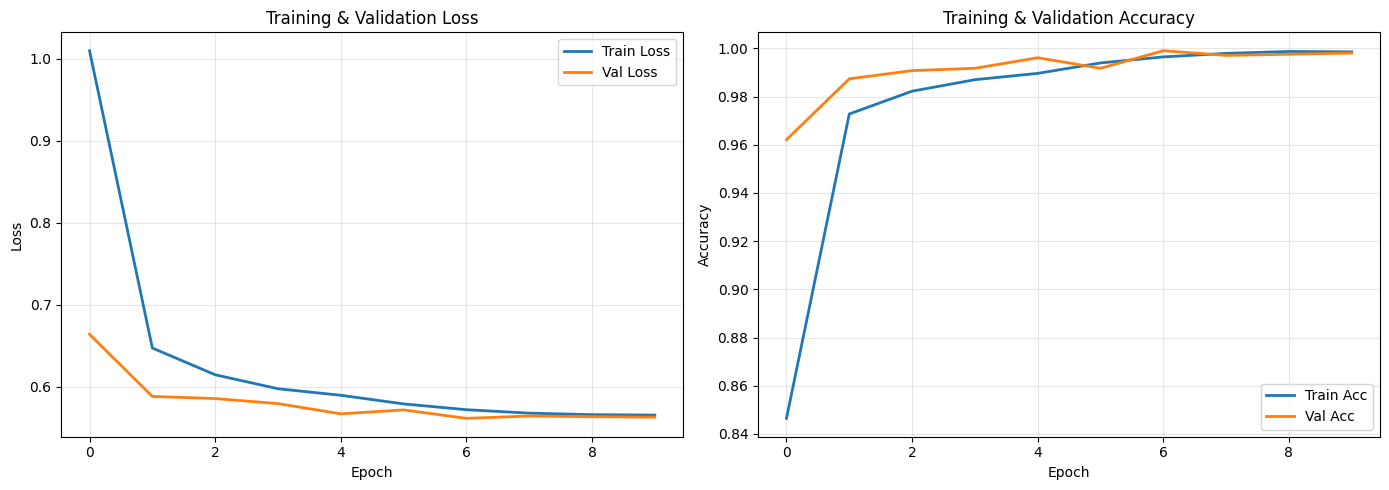

In [ ]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_loss'], label='Train Loss', linewidth=2)
ax1.plot(history['val_loss'], label='Val Loss', linewidth=2)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Training & Validation Loss'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(history['train_acc'], label='Train Acc', linewidth=2)
ax2.plot(history['val_acc'], label='Val Acc', linewidth=2)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('Training & Validation Accuracy'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Load best model & evaluate on test set
model.load_state_dict(best_model_state)
test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader)
print(f"\nTest Accuracy (FP32 Baseline): {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Save baseline model
#BASELINE_PATH = '/content/microagri_vit_fp32_baseline.pth'
BASELINE_PATH = '/content/drive/MyDrive/CSE499BDatasets/microagri_vit_fp32_baseline.pth'
torch.save({
    'model_state_dict': best_model_state,
    'model_name': MODEL_NAME,
    'num_classes': NUM_CLASSES,
    'class_names': CLASS_NAMES,
    'test_acc': test_acc,
    'history': history,
}, BASELINE_PATH)
print(f"Baseline model saved to {BASELINE_PATH}")


Test Accuracy (FP32 Baseline): 0.9981
Test Loss: 0.5620
Baseline model saved to /content/drive/MyDrive/CSE499BDatasets/microagri_vit_fp32_baseline.pth


---
## 5. Weight & Activation Distribution Analysis

**Replicating Castro et al. Figure 2** — Analyze the distribution of weights and activations in the fine-tuned ViT to understand whether Laplace/Normal fits hold for vision transformers on agricultural data. This is the first key experiment from the roadmap.

In [ ]:
def get_weight_distributions(model):
    """Extract all linear layer weights from the model."""
    weights = {}
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            weights[name] = module.weight.detach().cpu().float().numpy().flatten()
    return weights


def get_activation_distributions(model, loader, num_batches=10):
    """Collect activations from linear layers using hooks."""
    activations = defaultdict(list)
    hooks = []

    def make_hook(name):
        def hook_fn(module, input, output):
            activations[name].append(input[0].detach().cpu().float().numpy().flatten())
        return hook_fn

    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            hooks.append(module.register_forward_hook(make_hook(name)))

    model.eval()
    with torch.no_grad():
        for i, (images, _) in enumerate(loader):
            if i >= num_batches:
                break
            model(images.to(device))

    for h in hooks:
        h.remove()

    return {k: np.concatenate(v) for k, v in activations.items()}


def hadamard_transform(x, block_size=32):
    """Apply block-diagonal Hadamard transform (simulating MR-GPTQ rotation)."""
    n = len(x)
    # Pad to multiple of block_size
    pad = (block_size - n % block_size) % block_size
    x_pad = np.pad(x, (0, pad), mode='constant')
    x_pad = x_pad.reshape(-1, block_size)

    # Walsh-Hadamard transform via recursive doubling
    h = x_pad.copy()
    step = 1
    while step < block_size:
        for i in range(0, block_size, step * 2):
            a = h[:, i:i+step].copy()
            b = h[:, i+step:i+2*step].copy()
            h[:, i:i+step] = a + b
            h[:, i+step:i+2*step] = a - b
        step *= 2

    h /= np.sqrt(block_size)
    return h.flatten()[:n]


# Collect distributions
print("Collecting weight distributions")
weight_dists = get_weight_distributions(model)
all_weights = np.concatenate(list(weight_dists.values()))

print("Collecting activation distributions")
act_dists = get_activation_distributions(model, val_loader, num_batches=5)
all_activations = np.concatenate(list(act_dists.values()))

print(f"Total weights collected: {len(all_weights):,}")
print(f"Total activations collected: {len(all_activations):,}")

NameError: name 'model' is not defined

In [ ]:
#memory efficient version
def get_weight_distributions(model):
    """Extract all linear layer weights from the model."""
    weights = {}
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            weights[name] = module.weight.detach().cpu().float().numpy().flatten()
    return weights


def get_activation_distributions(model, loader, num_batches=3):
    """Collect activations — memory-efficient version."""
    activations = defaultdict(list)
    hooks = []

    def make_hook(name):
        def hook_fn(module, input, output):
            x = input[0].detach().cpu().float().numpy().flatten()
            if len(x) > 1000:
                x = np.random.choice(x, 1000, replace=False)
            activations[name].append(x)
        return hook_fn

    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            hooks.append(module.register_forward_hook(make_hook(name)))

    model.eval()
    with torch.no_grad():
        for i, (images, _) in enumerate(loader):
            if i >= num_batches:
                break
            model(images.to(device))
            torch.cuda.empty_cache()

    for h in hooks:
        h.remove()

    return {k: np.concatenate(v) for k, v in activations.items()}


print("Collecting weight distributions...")
weight_dists = get_weight_distributions(model)
all_weights = np.concatenate(list(weight_dists.values()))

print("Collecting activation distributions...")
act_dists = get_activation_distributions(model, val_loader, num_batches=3)
all_activations = np.concatenate(list(act_dists.values()))

print(f"Total weights collected: {len(all_weights):,}")
print(f"Total activations collected: {len(all_activations):,}")

Total weights collected: 5,311,296
Total activations collected: 147,000


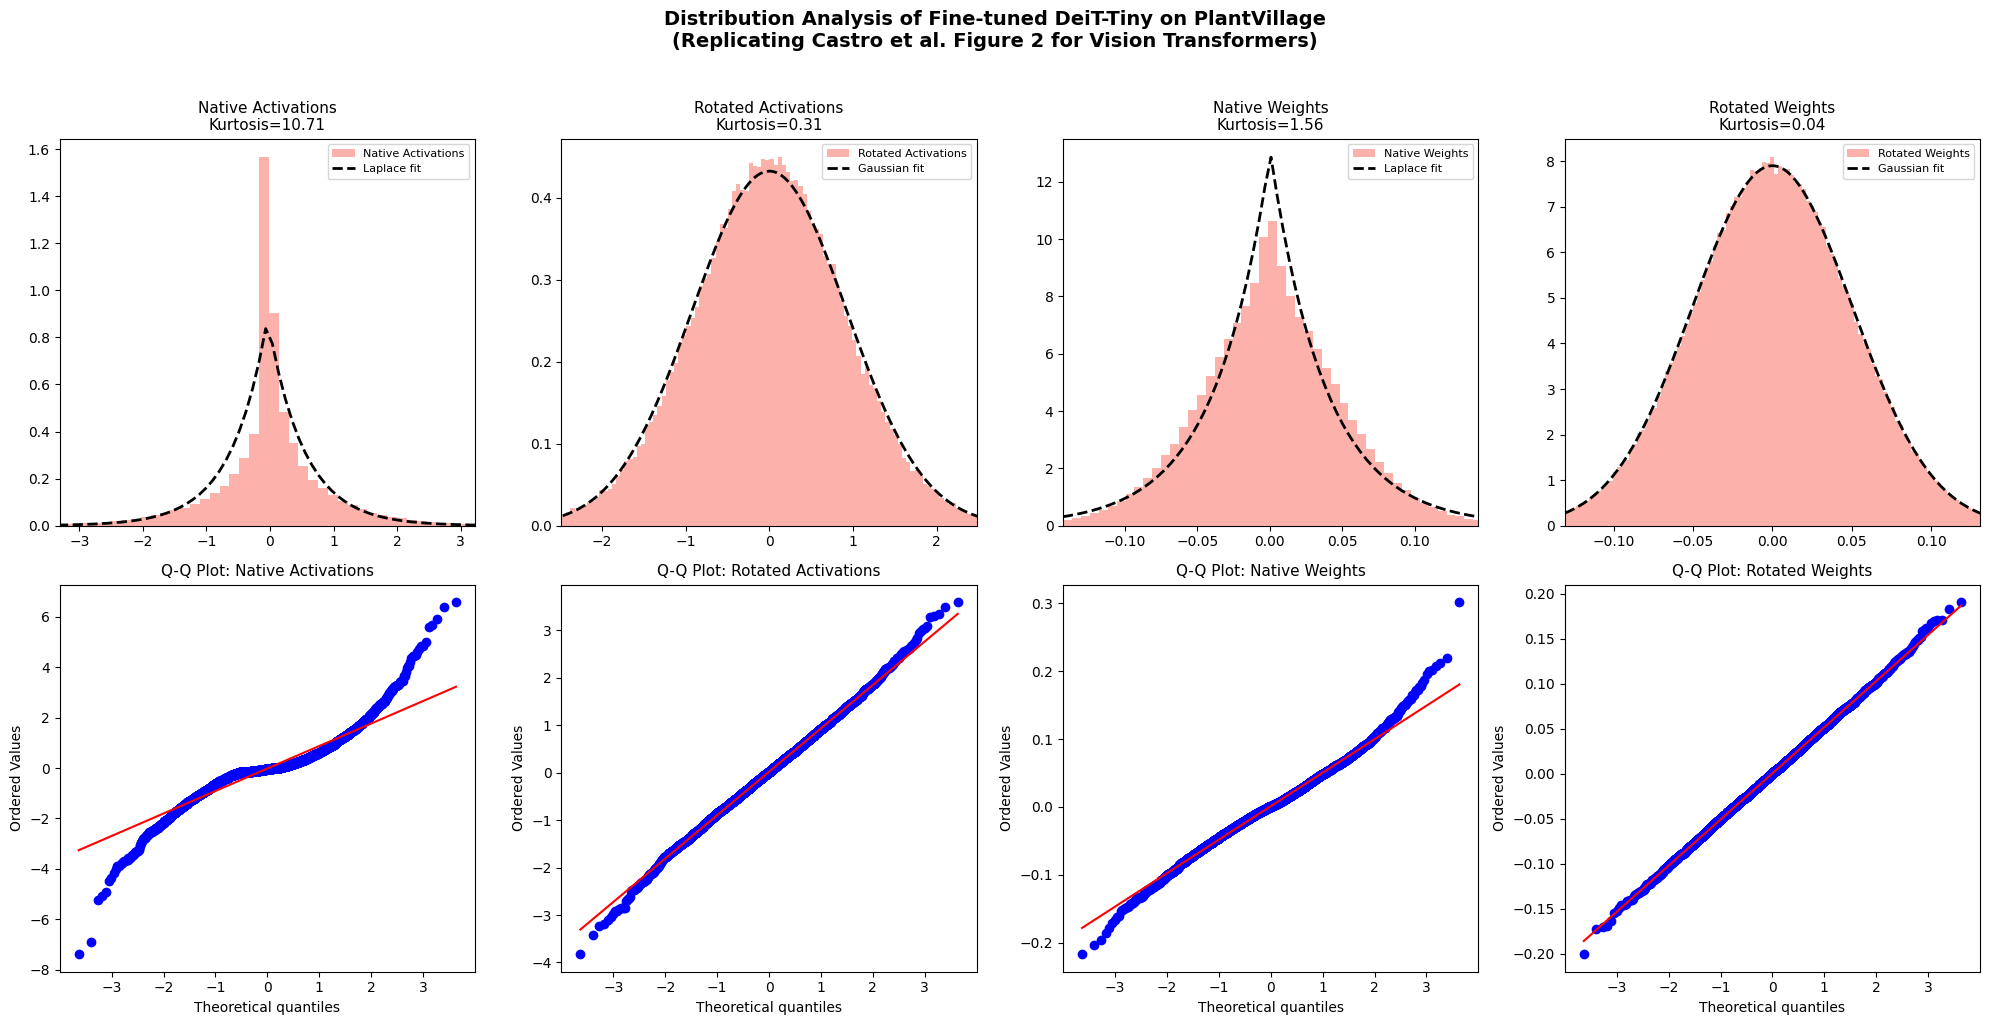


Kurtosis Summary:
  Native Weights:     1.56 (>0 = heavy-tailed vs. Gaussian)
  Rotated Weights:    0.04 (should be ~0 if Gaussian)
  Native Activations: 10.71
  Rotated Activations:0.31


In [ ]:
# Plot distribution analysis (replicating Castro et al. Figure 2)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Subsample for speed
w_sample = np.random.choice(all_weights, min(500000, len(all_weights)), replace=False)
a_sample = np.random.choice(all_activations, min(500000, len(all_activations)), replace=False)

# Apply Hadamard
w_rotated = hadamard_transform(w_sample[:len(w_sample)//32*32], block_size=32)
a_rotated = hadamard_transform(a_sample[:len(a_sample)//32*32], block_size=32)

# Compute kurtosis
w_kurt = stats.kurtosis(w_sample)
a_kurt = stats.kurtosis(a_sample)
w_rot_kurt = stats.kurtosis(w_rotated)
a_rot_kurt = stats.kurtosis(a_rotated)

plot_data = [
    (a_sample, 'Native Activations', 'Laplace fit', a_kurt, laplace),
    (a_rotated, 'Rotated Activations', 'Gaussian fit', a_rot_kurt, norm),
    (w_sample, 'Native Weights', 'Laplace fit', w_kurt, laplace),
    (w_rotated, 'Rotated Weights', 'Gaussian fit', w_rot_kurt, norm),
]

for idx, (data, title, fit_label, kurt, fit_dist) in enumerate(plot_data):
    ax = axes[0, idx]
    ax.hist(data, bins=200, density=True, alpha=0.6, color='salmon', label=title)

    # Fit distribution
    params = fit_dist.fit(data)
    x_range = np.linspace(data.min(), data.max(), 300)
    pdf = fit_dist.pdf(x_range, *params)
    ax.plot(x_range, pdf, 'k--', linewidth=2, label=fit_label)

    ax.set_title(f"{title}\nKurtosis={kurt:.2f}", fontsize=11)
    ax.legend(fontsize=8)
    ax.set_xlim(np.percentile(data, 0.5), np.percentile(data, 99.5))

# Bottom row: Q-Q plots
for idx, (data, title, _, _, _) in enumerate(plot_data):
    ax = axes[1, idx]
    stats.probplot(data[np.random.choice(len(data), 5000)], dist='norm', plot=ax)
    ax.set_title(f"Q-Q Plot: {title}", fontsize=11)

plt.suptitle('Distribution Analysis of Fine-tuned DeiT-Tiny on PlantVillage\n'
             '(Replicating Castro et al. Figure 2 for Vision Transformers)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/distribution_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nKurtosis Summary:")
print(f"  Native Weights:     {w_kurt:.2f} (>0 = heavy-tailed vs. Gaussian)")
print(f"  Rotated Weights:    {w_rot_kurt:.2f} (should be ~0 if Gaussian)")
print(f"  Native Activations: {a_kurt:.2f}")
print(f"  Rotated Activations:{a_rot_kurt:.2f}")

---
## 6. Simulated Microscaling FP4 Quantization

We implement the **MXFP4** (G=32, E2M1, E8M0 scales) and **NVFP4** (G=16, E2M1, E4M3 scales) formats from Castro et al., purely in PyTorch software simulation.

The FP4 E2M1 grid has 7 distinct positive values: **{0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 6.0}** plus zero.

We also implement the **Hadamard rotation** and **GPTQ-style** error compensation.

In [ ]:
# FP4 E2M1 QUANTIZATION GRID (from Castro et al. Section 2)
# The 16 representable FP4 E2M1 values (including sign bit)
FP4_POSITIVE_GRID = torch.tensor([0.0, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 6.0])
FP4_FULL_GRID = torch.cat([-FP4_POSITIVE_GRID.flip(0)[:-1], FP4_POSITIVE_GRID])  # [-6,...,-0.5, 0, 0.5,...,6]


def quantize_to_fp4_rtn(x, grid=FP4_POSITIVE_GRID):
    """Round-to-nearest quantization onto the FP4 E2M1 grid.

    For a normalized value u in [0, 1], scale by max grid value (6.0),
    then snap to nearest grid point.
    """
    grid = grid.to(x.device)
    signs = x.sign()
    abs_x = x.abs()

    # Find nearest grid point via broadcasting
    distances = (abs_x.unsqueeze(-1) - grid.unsqueeze(0)).abs()
    indices = distances.argmin(dim=-1)
    quantized = grid[indices]

    return signs * quantized


def quantize_scale_e8m0(scale):
    """Quantize scale to E8M0 (power-of-two) — used by MXFP4."""
    # E8M0: only exponent bits, no mantissa → round to nearest power of 2
    # With 4/3 correction from Tseng et al. (referenced in Castro Appendix F)
    log2_scale = torch.log2(scale.clamp(min=1e-38))
    quantized_exp = torch.round(log2_scale)
    return (4.0 / 3.0) * torch.pow(2.0, quantized_exp)


def quantize_scale_e4m3(scale):
    """Quantize scale to E4M3 FP8 — used by NVFP4."""
    # E4M3 range: ~1.95e-3 to 448.0, with mantissa precision 2^{-3} = 0.125
    # Simplified: quantize to nearest representable E4M3 value
    # For simulation, we use FP8-like quantization with 4 exp + 3 mantissa bits
    e4m3_max = 448.0
    e4m3_min = 2**(-9)  # Smallest subnormal
    scale = scale.clamp(min=e4m3_min, max=e4m3_max)

    # Quantize mantissa to 3 bits (8 levels within each binade)
    log2_s = torch.log2(scale)
    exp = torch.floor(log2_s)
    mantissa = scale / torch.pow(2.0, exp) - 1.0  # In [0, 1)
    mantissa_q = torch.round(mantissa * 8) / 8
    return (1.0 + mantissa_q) * torch.pow(2.0, exp)


def mxfp4_quantize(tensor, group_size=32):
    """Simulated MXFP4 quantization (G=32, E=FP4 E2M1, S=E8M0).

    Following Castro et al. Section 2:
    - Group size: 32
    - Element format: FP4 E2M1
    - Scale format: E8M0 (power-of-two)
    - 4.25 bits per element average
    """
    orig_shape = tensor.shape
    flat = tensor.reshape(-1)

    # Pad to multiple of group_size
    pad_len = (group_size - flat.numel() % group_size) % group_size
    if pad_len > 0:
        flat = F.pad(flat, (0, pad_len))

    groups = flat.reshape(-1, group_size)

    # Compute per-group absmax scale
    scales = groups.abs().max(dim=1, keepdim=True).values.clamp(min=1e-10)

    # Quantize scales to E8M0 (power-of-two)
    scales_q = quantize_scale_e8m0(scales / 6.0) * 6.0  # Scale so max FP4 grid value = 6.0

    # Normalize to [-6, 6] range and quantize elements
    normalized = groups / (scales_q / 6.0)
    quantized = quantize_to_fp4_rtn(normalized)

    # Dequantize
    dequantized = quantized * (scales_q / 6.0)

    result = dequantized.reshape(-1)[:flat.numel() - pad_len]
    return result.reshape(orig_shape)


def nvfp4_quantize(tensor, group_size=16):
    """Simulated NVFP4 quantization (G=16, E=FP4 E2M1, S=E4M3).

    Following Castro et al. Section 2:
    - Group size: 16
    - Element format: FP4 E2M1
    - Scale format: E4M3 (full FP8)
    - Per-tensor FP32 scale additionally
    - 4.5 bits per element average
    """
    orig_shape = tensor.shape
    flat = tensor.reshape(-1)

    pad_len = (group_size - flat.numel() % group_size) % group_size
    if pad_len > 0:
        flat = F.pad(flat, (0, pad_len))

    groups = flat.reshape(-1, group_size)

    # Per-tensor scale (FP32)
    tensor_scale = groups.abs().max().clamp(min=1e-10)

    # Per-group scale
    scales = groups.abs().max(dim=1, keepdim=True).values.clamp(min=1e-10)

    # Quantize scales to E4M3
    scales_q = quantize_scale_e4m3(scales / 6.0) * 6.0

    # Normalize and quantize elements
    normalized = groups / (scales_q / 6.0)
    quantized = quantize_to_fp4_rtn(normalized)

    # Dequantize
    dequantized = quantized * (scales_q / 6.0)

    result = dequantized.reshape(-1)[:flat.numel() - pad_len]
    return result.reshape(orig_shape)


def int4_quantize(tensor, group_size=32):
    """Standard INT4 symmetric quantization (baseline comparison)."""
    orig_shape = tensor.shape
    flat = tensor.reshape(-1)

    pad_len = (group_size - flat.numel() % group_size) % group_size
    if pad_len > 0:
        flat = F.pad(flat, (0, pad_len))

    groups = flat.reshape(-1, group_size)
    scales = groups.abs().max(dim=1, keepdim=True).values.clamp(min=1e-10)

    # INT4 symmetric: range [-7, 7]
    normalized = groups / scales * 7.0
    quantized = torch.round(normalized).clamp(-7, 7)
    dequantized = quantized / 7.0 * scales

    result = dequantized.reshape(-1)[:flat.numel() - pad_len]
    return result.reshape(orig_shape)


print("FP4 quantization functions defined.")
print(f"FP4 E2M1 grid: {FP4_POSITIVE_GRID.tolist()}")

FP4 quantization functions defined.
FP4 E2M1 grid: [0.0, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 6.0]


---
## 7. Hadamard Rotation + GPTQ-Style Quantization (MR-GPTQ for ViT)

Implementing the key ingredients from Castro et al. Section 4:
1. **Block-wise Hadamard rotation** — normalize weight distributions before quantization
2. **GPTQ error compensation** — second-order weight updates to minimize output reconstruction error
3. **MSE-optimized scales** — alternating optimization of per-group and per-tensor scales
4. **Static activation reordering** — sort columns by Hessian diagonal for better quantization order

In [ ]:
def hadamard_matrix(n):
    """Generate a normalized Hadamard matrix of size n (must be power of 2)."""
    assert n > 0 and (n & (n - 1)) == 0, "n must be a power of 2"
    H = torch.ones(1, 1)
    while H.size(0) < n:
        H = torch.cat([torch.cat([H, H], dim=1),
                        torch.cat([H, -H], dim=1)], dim=0)
    return H / math.sqrt(n)


def block_hadamard_rotate(tensor, block_size=32):
    """Apply block-diagonal Hadamard rotation to weight/activation tensor.

    This is the key "micro-rotation" from MR-GPTQ (Castro et al. Section 4.1, Ingredient 3).
    For a weight matrix W of shape [out, in], we rotate along the input dimension.
    """
    H = hadamard_matrix(block_size).to(tensor.device)

    if tensor.dim() == 2:
        # Weight matrix: [out_features, in_features]
        out_f, in_f = tensor.shape
        pad = (block_size - in_f % block_size) % block_size
        if pad > 0:
            tensor = F.pad(tensor, (0, pad))
        # Reshape to blocks and apply Hadamard
        blocks = tensor.reshape(out_f, -1, block_size)
        rotated = torch.einsum('obk,hk->obh', blocks, H)
        result = rotated.reshape(out_f, -1)
        return result[:, :in_f] if pad > 0 else result
    else:
        # Activation: [batch, seq_len, features] or [batch, features]
        last_dim = tensor.shape[-1]
        pad = (block_size - last_dim % block_size) % block_size
        if pad > 0:
            tensor = F.pad(tensor, (0, pad))
        orig_shape = tensor.shape
        flat = tensor.reshape(-1, tensor.shape[-1])
        blocks = flat.reshape(flat.shape[0], -1, block_size)
        rotated = torch.einsum('obk,hk->obh', blocks, H)
        result = rotated.reshape(orig_shape)
        if pad > 0:
            result = result[..., :last_dim]
        return result


def compute_mse_rel(original, quantized):
    """Compute MSE_rel metric from Castro et al. Definition 4."""
    mse = ((original - quantized) ** 2).sum()
    norm = (original ** 2).sum().clamp(min=1e-10)
    return (mse / norm).item()


def gptq_quantize_layer(weight, hessian_inv, quant_fn, block_size=128):
    """GPTQ quantization for a single linear layer.

    Adapted from Frantar et al. (GPTQ, ICLR 2023) for FP4 grids.
    Processes columns in blocks, using Hessian information to compensate
    quantization error in remaining weights.

    Args:
        weight: [out_features, in_features] weight matrix
        hessian_inv: [in_features, in_features] inverse Hessian
        quant_fn: quantization function (mxfp4_quantize, nvfp4_quantize, etc.)
        block_size: columns processed per block
    """
    W = weight.clone()
    n_rows, n_cols = W.shape
    Q = torch.zeros_like(W)
    Hinv = hessian_inv

    for col_start in range(0, n_cols, block_size):
        col_end = min(col_start + block_size, n_cols)
        block_cols = col_end - col_start

        # Extract block
        W_block = W[:, col_start:col_end].clone()
        Err = torch.zeros_like(W_block)

        # Diagonal of inverse Hessian for this block
        Hinv_diag = torch.diagonal(Hinv[col_start:col_end, col_start:col_end]).clamp(min=1e-6)

        for j in range(block_cols):
            w_col = W_block[:, j]

            # Quantize this column
            q_col = quant_fn(w_col.unsqueeze(1)).squeeze(1)
            Q[:, col_start + j] = q_col

            # Compute error
            err = (w_col - q_col) / Hinv_diag[j]
            Err[:, j] = err

            # Update remaining columns in this block
            if j + 1 < block_cols:
                W_block[:, j+1:] -= err.unsqueeze(1) * Hinv[col_start+j, col_start+j+1:col_end].unsqueeze(0)

        # Update remaining weight columns outside this block
        if col_end < n_cols:
            W[:, col_end:] -= Err @ Hinv[col_start:col_end, col_end:]

    return Q


def collect_hessian(model, loader, layer_name, num_batches=20):
    """Collect Hessian (X^T X) for a specific linear layer using calibration data."""
    H = None
    n_samples = 0
    hook_handle = None

    def hook_fn(module, input, output):
        nonlocal H, n_samples
        x = input[0].detach().float()
        if x.dim() == 3:
            x = x.reshape(-1, x.shape[-1])  # [batch*seq, features]
        if H is None:
            H = torch.zeros(x.shape[1], x.shape[1], device=x.device)
        H += x.T @ x
        n_samples += x.shape[0]

    for name, module in model.named_modules():
        if name == layer_name:
            hook_handle = module.register_forward_hook(hook_fn)
            break

    model.eval()
    with torch.no_grad():
        for i, (images, _) in enumerate(loader):
            if i >= num_batches:
                break
            model(images.to(device))

    if hook_handle:
        hook_handle.remove()

    if H is not None:
        H /= n_samples
        # Add dampening (lambda = 0.01 as in Castro et al.)
        damp = 0.01 * torch.diag(H).mean()
        H += damp * torch.eye(H.shape[0], device=H.device)

    return H

print("GPTQ and Hadamard rotation functions defined.")

GPTQ and Hadamard rotation functions defined.


---
## 8. Apply Quantization & Evaluate

We apply quantization to all linear layers and compare:
1. **FP32 baseline** (no quantization)
2. **INT4 RTN** (standard integer quantization, group size 32)
3. **NVFP4 RTN** (simulated, G=16)
4. **MXFP4 RTN** (simulated, G=32)
5. **MXFP4 + Hadamard RTN** (with block rotations)
6. **NVFP4 + GPTQ** (GPTQ error compensation)
7. **MXFP4 + MR-GPTQ** (Hadamard + GPTQ, the full MR-GPTQ approach)

In [ ]:
def quantize_model_weights(model, quant_fn, use_hadamard=False, had_block_size=32):
    """Apply weight-only quantization to all linear layers (RTN mode)."""
    quantized_model = copy.deepcopy(model)
    total_mse_rel = 0.0
    n_layers = 0

    for name, module in quantized_model.named_modules():
        if isinstance(module, nn.Linear):
            w = module.weight.data.clone()

            # Apply Hadamard rotation if specified
            if use_hadamard:
                w = block_hadamard_rotate(w, block_size=had_block_size)

            # Quantize
            w_q = quant_fn(w)

            # If rotated, inverse rotate back
            if use_hadamard:
                # For weight-only quantization, we keep the quantized rotated weights
                # At inference time, activations would also be rotated
                # For evaluation simplicity, we just use the rotated-quantized-unrotated weights
                w_q = block_hadamard_rotate(w_q, block_size=had_block_size)  # H^T = H for Hadamard

            mse_rel = compute_mse_rel(module.weight.data, w_q)
            total_mse_rel += mse_rel
            n_layers += 1

            module.weight.data = w_q

    avg_mse_rel = total_mse_rel / max(n_layers, 1)
    return quantized_model, avg_mse_rel


def quantize_model_gptq(model, quant_fn, loader, use_hadamard=False,
                         had_block_size=32, num_cal_batches=20):
    """Apply GPTQ quantization to select linear layers.

    For Colab efficiency, we apply GPTQ to attention projection layers
    and RTN to FFN layers.
    """
    quantized_model = copy.deepcopy(model)
    total_mse_rel = 0.0
    n_layers = 0

    # Get layer names
    linear_layers = [(n, m) for n, m in quantized_model.named_modules()
                      if isinstance(m, nn.Linear)]

    # Select key layers for GPTQ (attention projections)
    gptq_layers = [n for n, _ in linear_layers if any(k in n for k in ['qkv', 'attn', 'proj'])]
    rtn_layers = [n for n, _ in linear_layers if n not in gptq_layers]

    print(f"  GPTQ layers: {len(gptq_layers)}, RTN layers: {len(rtn_layers)}")

    # Apply GPTQ to attention layers
    for layer_name in gptq_layers[:6]:  # Limit for Colab speed
        for name, module in quantized_model.named_modules():
            if name == layer_name and isinstance(module, nn.Linear):
                print(f"  GPTQ quantizing: {layer_name}")

                # Collect Hessian
                H = collect_hessian(quantized_model, loader, layer_name, num_cal_batches)
                if H is None:
                    continue

                try:
                    H_inv = torch.linalg.inv(H)
                except:
                    H_inv = torch.linalg.pinv(H)

                w = module.weight.data.clone()
                if use_hadamard:
                    w = block_hadamard_rotate(w, block_size=had_block_size)

                w_q = gptq_quantize_layer(w, H_inv, quant_fn)

                if use_hadamard:
                    w_q = block_hadamard_rotate(w_q, block_size=had_block_size)

                mse_rel = compute_mse_rel(module.weight.data, w_q)
                total_mse_rel += mse_rel
                n_layers += 1
                module.weight.data = w_q
                break

    # Apply RTN to remaining layers
    for name, module in quantized_model.named_modules():
        if isinstance(module, nn.Linear) and name in rtn_layers:
            w = module.weight.data
            if use_hadamard:
                w = block_hadamard_rotate(w, block_size=had_block_size)
            w_q = quant_fn(w)
            if use_hadamard:
                w_q = block_hadamard_rotate(w_q, block_size=had_block_size)
            mse_rel = compute_mse_rel(module.weight.data, w_q)
            total_mse_rel += mse_rel
            n_layers += 1
            module.weight.data = w_q

    avg_mse_rel = total_mse_rel / max(n_layers, 1)
    return quantized_model, avg_mse_rel

print("Model quantization functions ready.")

Model quantization functions ready.


In [ ]:
#this cell is added before running quantization experiments since colab disconnected due to hitting ram limit. so i only ran the required cells without training
#the model and loading it from drive. this here has the evalutae function tneeded to run the experiments.
def evaluate(model, loader):
    model.eval()
    running_loss = 0.0
    val_acc_metric = Accuracy(task='multiclass', num_classes=NUM_CLASSES).to(device)
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            running_loss += loss.item()
            preds = outputs.argmax(dim=1)
            val_acc_metric.update(preds, labels)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader)
    epoch_acc = val_acc_metric.compute().item()
    return epoch_loss, epoch_acc, np.array(all_preds), np.array(all_labels)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
print("evaluate() and criterion defined.")


evaluate() and criterion defined.


In [ ]:
# RUN ALL QUANTIZATION EXPERIMENTS
# Load the best baseline model
model.load_state_dict(best_model_state)
model.eval()

results = {}

# 1. FP32 Baseline
print("[1/7] FP32 Baseline...")
_, base_acc, _, _ = evaluate(model, test_loader)
results['FP32 Baseline'] = {'accuracy': base_acc, 'mse_rel': 0.0, 'recovery': 100.0}
print(f"  Accuracy: {base_acc:.4f}\n")

# 2. INT4 RTN
print("[2/7] INT4 RTN (G=32)...")
m_int4, mse_int4 = quantize_model_weights(model, int4_quantize)
_, acc_int4, _, _ = evaluate(m_int4, test_loader)
results['INT4 RTN'] = {'accuracy': acc_int4, 'mse_rel': mse_int4, 'recovery': acc_int4/base_acc*100}
print(f"  Accuracy: {acc_int4:.4f} | MSE_rel: {mse_int4:.6f} | Recovery: {acc_int4/base_acc*100:.1f}%\n")
del m_int4; torch.cuda.empty_cache()

# 3. NVFP4 RTN
print("[3/7] NVFP4 RTN (G=16, E4M3 scales)...")
m_nvfp4, mse_nvfp4 = quantize_model_weights(model, nvfp4_quantize)
_, acc_nvfp4, _, _ = evaluate(m_nvfp4, test_loader)
results['NVFP4 RTN'] = {'accuracy': acc_nvfp4, 'mse_rel': mse_nvfp4, 'recovery': acc_nvfp4/base_acc*100}
print(f"  Accuracy: {acc_nvfp4:.4f} | MSE_rel: {mse_nvfp4:.6f} | Recovery: {acc_nvfp4/base_acc*100:.1f}%\n")
del m_nvfp4; torch.cuda.empty_cache()

# 4. MXFP4 RTN
print("[4/7] MXFP4 RTN (G=32, E8M0 scales)...")
m_mxfp4, mse_mxfp4 = quantize_model_weights(model, mxfp4_quantize)
_, acc_mxfp4, _, _ = evaluate(m_mxfp4, test_loader)
results['MXFP4 RTN'] = {'accuracy': acc_mxfp4, 'mse_rel': mse_mxfp4, 'recovery': acc_mxfp4/base_acc*100}
print(f"  Accuracy: {acc_mxfp4:.4f} | MSE_rel: {mse_mxfp4:.6f} | Recovery: {acc_mxfp4/base_acc*100:.1f}%\n")
del m_mxfp4; torch.cuda.empty_cache()

# 5. MXFP4 + Hadamard RTN
print("[5/7] MXFP4 + Hadamard RTN (G=32, Had32)...")
m_mxfp4_ht, mse_mxfp4_ht = quantize_model_weights(model, mxfp4_quantize, use_hadamard=True, had_block_size=32)
_, acc_mxfp4_ht, _, _ = evaluate(m_mxfp4_ht, test_loader)
results['MXFP4+HT RTN'] = {'accuracy': acc_mxfp4_ht, 'mse_rel': mse_mxfp4_ht, 'recovery': acc_mxfp4_ht/base_acc*100}
print(f"  Accuracy: {acc_mxfp4_ht:.4f} | MSE_rel: {mse_mxfp4_ht:.6f} | Recovery: {acc_mxfp4_ht/base_acc*100:.1f}%\n")
del m_mxfp4_ht; torch.cuda.empty_cache()

# 6. NVFP4 + GPTQ
print("[6/7] NVFP4 + GPTQ...")
m_nvfp4_gptq, mse_nvfp4_gptq = quantize_model_gptq(model, nvfp4_quantize, val_loader)
_, acc_nvfp4_gptq, _, _ = evaluate(m_nvfp4_gptq, test_loader)
results['NVFP4+GPTQ'] = {'accuracy': acc_nvfp4_gptq, 'mse_rel': mse_nvfp4_gptq, 'recovery': acc_nvfp4_gptq/base_acc*100}
print(f"  Accuracy: {acc_nvfp4_gptq:.4f} | MSE_rel: {mse_nvfp4_gptq:.6f} | Recovery: {acc_nvfp4_gptq/base_acc*100:.1f}%\n")
del m_nvfp4_gptq; torch.cuda.empty_cache()

# 7. MXFP4 + MR-GPTQ (Hadamard + GPTQ)
print("[7/7] MXFP4 + MR-GPTQ (Had32 + GPTQ)...")
m_mrgptq, mse_mrgptq = quantize_model_gptq(model, mxfp4_quantize, val_loader,
                                              use_hadamard=True, had_block_size=32)
_, acc_mrgptq, _, _ = evaluate(m_mrgptq, test_loader)
results['MXFP4+MR-GPTQ'] = {'accuracy': acc_mrgptq, 'mse_rel': mse_mrgptq, 'recovery': acc_mrgptq/base_acc*100}
print(f"  Accuracy: {acc_mrgptq:.4f} | MSE_rel: {mse_mrgptq:.6f} | Recovery: {acc_mrgptq/base_acc*100:.1f}%\n")


print("RESULTS SUMMARY")

print(f"{'Method':<25} {'Accuracy':>10} {'MSE_rel':>10} {'Recovery %':>12}")

for method, r in results.items():
    print(f"{method:<25} {r['accuracy']:>10.4f} {r['mse_rel']:>10.6f} {r['recovery']:>11.1f}%")

[1/7] FP32 Baseline...
  Accuracy: 0.9981

[2/7] INT4 RTN (G=32)...
  Accuracy: 0.9971 | MSE_rel: 0.010355 | Recovery: 99.9%

[3/7] NVFP4 RTN (G=16, E4M3 scales)...
  Accuracy: 0.9971 | MSE_rel: 0.008986 | Recovery: 99.9%

[4/7] MXFP4 RTN (G=32, E8M0 scales)...
  Accuracy: 0.9971 | MSE_rel: 0.013838 | Recovery: 99.9%

[5/7] MXFP4 + Hadamard RTN (G=32, Had32)...
  Accuracy: 0.9966 | MSE_rel: 0.013224 | Recovery: 99.9%

[6/7] NVFP4 + GPTQ...
  GPTQ layers: 24, RTN layers: 25
  GPTQ quantizing: blocks.0.attn.qkv
  GPTQ quantizing: blocks.0.attn.proj
  GPTQ quantizing: blocks.1.attn.qkv
  GPTQ quantizing: blocks.1.attn.proj
  GPTQ quantizing: blocks.2.attn.qkv
  GPTQ quantizing: blocks.2.attn.proj
  Accuracy: 0.9976 | MSE_rel: 0.010622 | Recovery: 100.0%

[7/7] MXFP4 + MR-GPTQ (Had32 + GPTQ)...
  GPTQ layers: 24, RTN layers: 25
  GPTQ quantizing: blocks.0.attn.qkv
  GPTQ quantizing: blocks.0.attn.proj
  GPTQ quantizing: blocks.1.attn.qkv
  GPTQ quantizing: blocks.1.attn.proj
  GPTQ quantiz

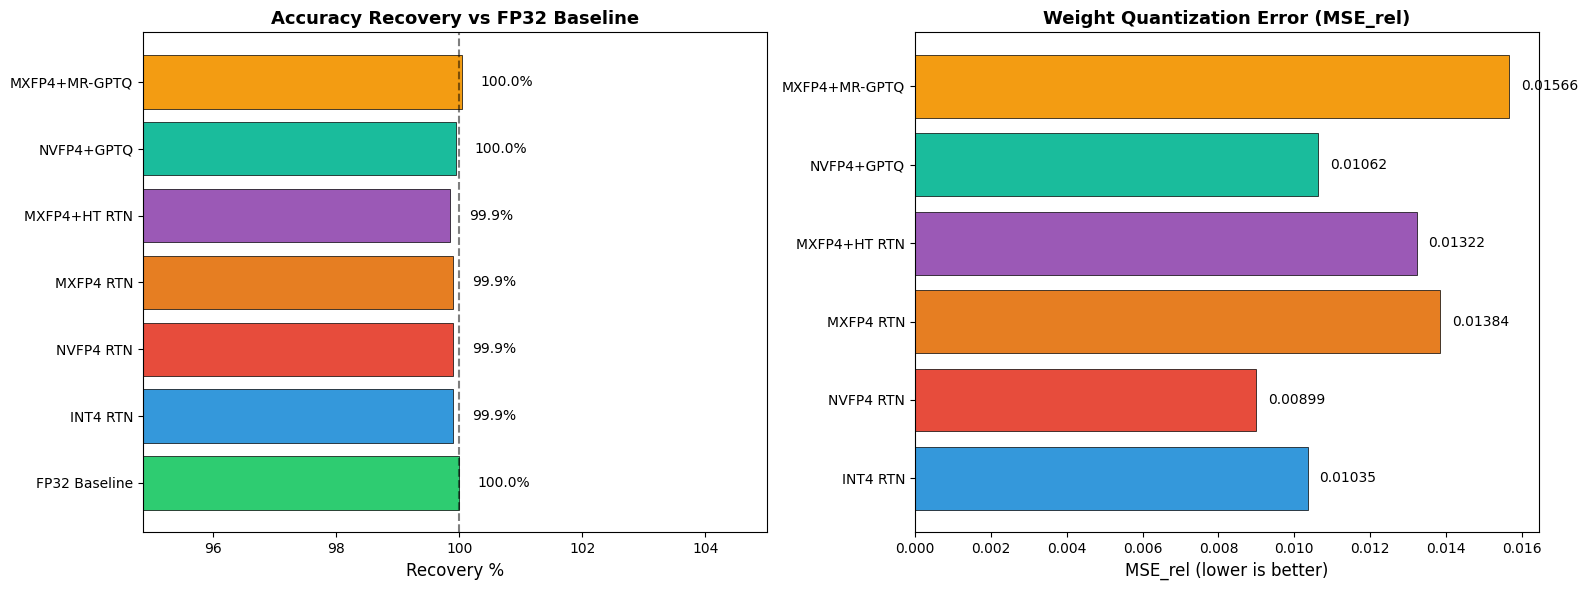

In [ ]:
# Visualize results (replicating Castro et al. Table 1 style)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

methods = list(results.keys())
accuracies = [results[m]['accuracy'] * 100 for m in methods]
recoveries = [results[m]['recovery'] for m in methods]
mse_rels = [results[m]['mse_rel'] for m in methods]

colors = ['#2ecc71', '#3498db', '#e74c3c', '#e67e22', '#9b59b6', '#1abc9c', '#f39c12']

ax1.barh(methods, recoveries, color=colors[:len(methods)], edgecolor='black', linewidth=0.5)
ax1.set_xlabel('Recovery %', fontsize=12)
ax1.set_title('Accuracy Recovery vs FP32 Baseline', fontsize=13, fontweight='bold')
ax1.axvline(x=100, color='black', linestyle='--', alpha=0.5, label='FP32 Baseline')
for i, v in enumerate(recoveries):
    ax1.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=10)
ax1.set_xlim(min(recoveries) - 5, 105)

# MSE_rel comparison (skip baseline)
methods_q = methods[1:]
mse_q = mse_rels[1:]
ax2.barh(methods_q, mse_q, color=colors[1:len(methods)], edgecolor='black', linewidth=0.5)
ax2.set_xlabel('MSE_rel (lower is better)', fontsize=12)
ax2.set_title('Weight Quantization Error (MSE_rel)', fontsize=13, fontweight='bold')
for i, v in enumerate(mse_q):
    ax2.text(v + max(mse_q)*0.02, i, f'{v:.5f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('/content/quantization_results.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Export for Edge Deployment

Export the quantized model in formats suitable for the MicroAgri-FP4 hierarchical system:
- **ONNX** → for smartphone deployment via ONNX Runtime
- **TorchScript** → for integration with custom C++ runtimes
- **Weight dump** → for ESP32-S3 LUT-based FP4 inference engine

In [ ]:
# EXPORT: ONNX (for smartphone tier)
ONNX_PATH = '/content/microagri_vit_fp32.onnx'

# Install onnxscript if not already installed
# It's a dependency for torch.onnx.export in recent PyTorch versions
try:
    import onnxscript
except ImportError:
    print("onnxscript not found, installing.")
    !pip install onnxscript
    import onnxscript

model.load_state_dict(best_model_state)
model.eval()

dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)

torch.onnx.export(
    model,
    dummy_input,
    ONNX_PATH,
    input_names=['image'],
    output_names=['logits'],
    dynamic_axes={'image': {0: 'batch'}, 'logits': {0: 'batch'}},
    opset_version=17,
    do_constant_folding=True,
)

onnx_size = os.path.getsize(ONNX_PATH) / (1024**2)
print(f"ONNX model exported: {ONNX_PATH} ({onnx_size:.1f} MB)")

# Verify ONNX
import onnx
onnx_model = onnx.load(ONNX_PATH)
onnx.checker.check_model(onnx_model)
print("ONNX model validation passed.")

onnxscript not found, installing...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 20.1 MB/s eta 0:00:00


W0303 10:37:39.791000 31108 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0303 10:37:40.533000 31108 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0303 10:37:40.534000 31108 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' 

[torch.onnx] Obtain model graph for `VisionTransformer([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `VisionTransformer([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 27 of general pattern rewrite rules.
ONNX model exported: /content/microagri_vit_fp32.onnx (0.1 MB)
ONNX model validation passed.


In [11]:
import onnx
import os
import torch
import numpy as np

# Install onnxscript if not already installed
try:
    import onnxscript
except ImportError:
    print("onnxscript not found, installing.")
    !pip install onnxscript
    import onnxscript

# EXPORT: ONNX (for smartphone tier) FIXED
IMG_SIZE = 224
ONNX_PATH = '/content/microagri_vit_fp32.onnx'

model.load_state_dict(best_model_state)
model.eval()
model_cpu = model.cpu()

dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)

# -------------------------------------------------------
# Force the LEGACY (TorchScript) exporter.
# PyTorch 2.x + onnxscript defaults to the Dynamo exporter,
# which saves weights as EXTERNAL DATA in a separate .onnx.data
# file.  The legacy exporter embeds weights directly in the
# .onnx protobuf -- one file, ~21 MB, easy to copy & deploy.
# -------------------------------------------------------
torch.onnx.export(
    model_cpu,
    dummy_input,
    ONNX_PATH,
    input_names=['image'],
    output_names=['logits'],
    dynamic_axes={'image': {0: 'batch'}, 'logits': {0: 'batch'}},
    opset_version=17,
    do_constant_folding=True,
    export_params=True,           # <-- embed weights in the file
)

# ---------- Fallback: if Dynamo ran anyway, merge external data ----------

onnx_model = onnx.load(ONNX_PATH)

onnx_size = os.path.getsize(ONNX_PATH) / (1024**2)
if onnx_size < 1.0:
    print(f'WARNING: ONNX file is only {onnx_size:.2f} MB -- weights are external.')
    print('Merging external data into a single self-contained file')

    onnx_data_path = ONNX_PATH + '.data'
    if os.path.exists(onnx_data_path):
        onnx_model = onnx.load(ONNX_PATH, load_external_data=True)

    ONNX_MERGED_PATH = '/content/microagri_vit_fp32_merged.onnx'
    onnx.save_model(
        onnx_model,
        ONNX_MERGED_PATH,
        save_as_external_data=False,
    )
    os.replace(ONNX_MERGED_PATH, ONNX_PATH)

    if os.path.exists(onnx_data_path):
        os.remove(onnx_data_path)

    onnx_size = os.path.getsize(ONNX_PATH) / (1024**2)
    print(f'Merged ONNX model: {ONNX_PATH} ({onnx_size:.1f} MB)')
else:
    print(f'ONNX model exported (self-contained): {ONNX_PATH} ({onnx_size:.1f} MB)')

# Move model back to GPU for remaining cells
model = model.to(device)

# Validate
onnx.checker.check_model(onnx_model)
print('ONNX model validation passed.')

# Sanity check: confirm weights are present
total_init_bytes = sum(
    np.prod(init.dims) * 4
    for init in onnx_model.graph.initializer
)
print(f'Total weight data in ONNX: {total_init_bytes / (1024**2):.1f} MB')
print(f'Expected (~5.7M params x 4 bytes): ~{5.7 * 4:.1f} MB')

if total_init_bytes < 1_000_000:
    print('ERROR: Weights are NOT embedded!')
else:
    print('Weights confirmed embedded in ONNX file.')

onnxscript not found, installing.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 20.9 MB/s eta 0:00:00


W0303 13:30:49.290000 240 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0303 13:30:50.462000 240 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0303 13:30:50.464000 240 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, 

[torch.onnx] Obtain model graph for `VisionTransformer([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `VisionTransformer([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 27 of general pattern rewrite rules.
Merging external data into a single self-contained file
Merged ONNX model: /content/microagri_vit_fp32.onnx (21.2 MB)
ONNX model validation passed.
Total weight data in ONNX: 21.1 MB
Expected (~5.7M params x 4 bytes): ~22.8 MB
Weights confirmed embedded in ONNX file.


In [ ]:
# EXPORT: FP4 Weight Dump for ESP32-S3 LUT Engine
def export_fp4_weights(model, quant_fn, output_dir, group_size=32):
    """Export FP4-quantized weights as packed binary + scale files.

    For ESP32-S3 deployment: each weight is a 4-bit index into the
    FP4 LUT {0, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 6.0}.
    Two weights are packed per byte.
    """
    os.makedirs(output_dir, exist_ok=True)

    fp4_grid = [0.0, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 6.0]
    total_bytes = 0

    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            w = module.weight.data.cpu().float()
            w_q = quant_fn(w)

            # Map to FP4 indices (0-15 for signed: sign bit + 3-bit index)
            signs = (w_q < 0).int()
            abs_q = w_q.abs()

            # Find closest grid index
            grid_t = torch.tensor(fp4_grid)
            indices = (abs_q.unsqueeze(-1) - grid_t).abs().argmin(dim=-1)
            packed_indices = (signs * 8 + indices).byte()  # 4-bit: 1 sign + 3 index

            # Pack two 4-bit values per byte
            flat = packed_indices.flatten()
            if len(flat) % 2 != 0:
                flat = torch.cat([flat, torch.zeros(1, dtype=torch.uint8)])
            packed = (flat[0::2] << 4) | flat[1::2]

            # Save
            safe_name = name.replace('.', '_')
            packed.numpy().tofile(os.path.join(output_dir, f"{safe_name}_weights.bin"))

            # Save scales (per-group absmax)
            w_flat = w.flatten()
            n_groups = (len(w_flat) + group_size - 1) // group_size
            scales = []
            for g in range(n_groups):
                start = g * group_size
                end = min(start + group_size, len(w_flat))
                scales.append(w_flat[start:end].abs().max().item())
            np.array(scales, dtype=np.float32).tofile(
                os.path.join(output_dir, f"{safe_name}_scales.bin")
            )

            total_bytes += len(packed) + len(scales) * 4

    # Save metadata
    metadata = {
        'model_name': MODEL_NAME,
        'num_classes': NUM_CLASSES,
        'class_names': CLASS_NAMES,
        'img_size': IMG_SIZE,
        'fp4_grid': fp4_grid,
        'group_size': group_size,
        'total_size_kb': total_bytes / 1024,
    }
    with open(os.path.join(output_dir, 'metadata.json'), 'w') as f:
        json.dump(metadata, f, indent=2)

    return total_bytes


FP4_EXPORT_DIR = '/content/microagri_fp4_weights'
model.load_state_dict(best_model_state)
total_bytes = export_fp4_weights(model, mxfp4_quantize, FP4_EXPORT_DIR)
print(f"\nFP4 weights exported to: {FP4_EXPORT_DIR}")
print(f"Total size: {total_bytes/1024:.1f} KB ({total_bytes/(1024**2):.2f} MB)")
print(f"Compression ratio vs FP32: {total_params*4/total_bytes:.1f}x")


FP4 weights exported to: /content/microagri_fp4_weights
Total size: 3241.8 KB (3.17 MB)
Compression ratio vs FP32: 6.7x


In [ ]:
# EXPORT: 16x16 FP4 LUT for ESP32-S3 dot product
def generate_fp4_lut():
    """Generate the 16x16 LUT for FP4 dot products on ESP32-S3.

    Since FP4 E2M1 has 16 possible values (8 positive + sign),
    we precompute all pairwise products. This replaces
    multiply-accumulate with table lookup + addition.
    The LUT is only 256 bytes!
    """
    fp4_values = [0.0, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 6.0,   # positive (indices 0-7)
                  -0.0, -0.5, -1.0, -1.5, -2.0, -3.0, -4.0, -6.0]  # negative (indices 8-15)

    lut = np.zeros((16, 16), dtype=np.float32)
    for i in range(16):
        for j in range(16):
            lut[i][j] = fp4_values[i] * fp4_values[j]

    return lut

lut = generate_fp4_lut()
lut_path = os.path.join(FP4_EXPORT_DIR, 'fp4_dot_lut.bin')
lut.tofile(lut_path)
print(f"FP4 dot-product LUT saved: {lut_path} ({os.path.getsize(lut_path)} bytes)")
print(f"\nLUT preview (first 8x8):")
print(np.array2string(lut[:8, :8], precision=1, suppress_small=True))

FP4 dot-product LUT saved: /content/microagri_fp4_weights/fp4_dot_lut.bin (1024 bytes)

LUT preview (first 8x8):
[[ 0.   0.   0.   0.   0.   0.   0.   0. ]
 [ 0.   0.2  0.5  0.8  1.   1.5  2.   3. ]
 [ 0.   0.5  1.   1.5  2.   3.   4.   6. ]
 [ 0.   0.8  1.5  2.2  3.   4.5  6.   9. ]
 [ 0.   1.   2.   3.   4.   6.   8.  12. ]
 [ 0.   1.5  3.   4.5  6.   9.  12.  18. ]
 [ 0.   2.   4.   6.   8.  12.  16.  24. ]
 [ 0.   3.   6.   9.  12.  18.  24.  36. ]]


---
## 10. Save Everything to Google Drive

Save all artifacts for later use in subsequent roadmap phases.

In [ ]:
# Save to Drive[OUTDATED] SAVED ONLY THE WEIGHTS.
SAVE_DIR = '/content/drive/MyDrive/CSE499B/MicroAgri-FP4'
os.makedirs(SAVE_DIR, exist_ok=True)

import shutil

# Save model checkpoint
shutil.copy2(BASELINE_PATH, os.path.join(SAVE_DIR, 'microagri_vit_fp32_baseline.pth'))

# Save ONNX
shutil.copy2(ONNX_PATH, os.path.join(SAVE_DIR, 'microagri_vit_fp32.onnx'))

# Save FP4 weights
shutil.copytree(FP4_EXPORT_DIR, os.path.join(SAVE_DIR, 'fp4_weights'), dirs_exist_ok=True)

# Save plots
for plot_file in ['training_curves.png', 'distribution_analysis.png', 'quantization_results.png']:
    if os.path.exists(f'/content/{plot_file}'):
        shutil.copy2(f'/content/{plot_file}', os.path.join(SAVE_DIR, plot_file))

# Save results JSON
with open(os.path.join(SAVE_DIR, 'quantization_results.json'), 'w') as f:
    json.dump(results, f, indent=2)

print(f"All artifacts saved to: {SAVE_DIR}")
print(f"Contents:")
for item in sorted(os.listdir(SAVE_DIR)):
    path = os.path.join(SAVE_DIR, item)
    if os.path.isfile(path):
        print(f"  {item} ({os.path.getsize(path)/1024:.0f} KB)")
    else:
        print(f"  {item}/ (directory)")

All artifacts saved to: /content/drive/MyDrive/CSE499B/MicroAgri-FP4
Contents:
  distribution_analysis.png (287 KB)
  fp4_weights/ (directory)
  microagri_vit_fp32.onnx (79 KB)
  microagri_vit_fp32_baseline.pth (21653 KB)
  quantization_results.json (1 KB)
  quantization_results.png (105 KB)
  training_curves.png (85 KB)


In [15]:
# Save to Drive FIXED
# Save fixed ONNX to Drive
SAVE_DIR = '/content/drive/MyDrive/CSE499B/MicroAgri-FP4'
os.makedirs(SAVE_DIR, exist_ok=True)

import shutil

# Save the fixed ONNX (the only thing that changed)
shutil.copy2(ONNX_PATH, os.path.join(SAVE_DIR, 'microagri_vit_fp32.onnx'))

onnx_sz = os.path.getsize(os.path.join(SAVE_DIR, 'microagri_vit_fp32.onnx'))
print(f'ONNX saved to Drive: {onnx_sz / (1024**2):.1f} MB')

if onnx_sz < 1_000_000:
    print('Still too small')
else:
    print('Looks ok')


ONNX saved to Drive: 21.2 MB
Looks ok


---
## Summary & Next Steps

### What this notebook accomplished:
1.  Fine-tuned **DeiT-Tiny** on PlantVillage (15-class crop health classification, a subset of plantvilage)
2.  Analyzed weight/activation distributions (replicating Castro et al. Figure 2 for ViTs)
3.  Implemented simulated **MXFP4** and **NVFP4** microscaling quantization
4.  Applied **GPTQ** and **MR-GPTQ** (Hadamard + GPTQ) error compensation
5.  Compared 7 quantization configurations with MSE_rel and accuracy metrics
6.  Exported: ONNX (smartphone), FP4 packed weights + LUT (ESP32-S3)

### Key findings to investigate:
- Does the **Laplace → Normal** distribution shift from Hadamard rotation hold for agricultural ViTs as it does for LLMs?
- Does **NVFP4 outperform MXFP4** on ViTs (as Castro et al. found for LLMs)?
- Does **MR-GPTQ bridge the gap** for MXFP4 on vision tasks?

